# Notebook 05 — Seasonal Disease Incidence Analysis

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Purpose
Demonstrate that **environmental factors independently drive gorilla illness** — not all
gorilla respiratory events are attributable to tourism. This is critical for:

1. Avoiding over-attribution of illness to tourists
2. Supporting more nuanced health policy (context-sensitive, not blanket closures)
3. Quantifying the baseline risk against which tourism risk is measured

### Rwanda Seasons (Meteorological Agency)
| Season | Months | Character |
|--------|--------|----------|
| Long Dry | Jun–Sep | Peak tourism, lower background illness |
| Short Dry | Dec–Feb | Secondary tourism peak |
| Long Wet | Mar–May | Low tourism, higher background illness |
| Short Wet | Oct–Nov | Moderate tourism, moderate illness |

### Methods
- Time series decomposition (trend + seasonal + residual)
- Spearman correlation: climate variables × illness counts
- Kruskal-Wallis: season × illness rate
- Negative binomial regression for overdispersed count data

## Cell 1 — Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.stats_utils import (
    run_kruskal_wallis_test,
    run_spearman_correlation,
    run_seasonal_attribution_test,
)
from src.viz_utils import set_style, save_fig, plot_seasonal_patterns, plot_group_month_heatmap, PALETTE

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
RPT_DIR  = PROJECT_ROOT / 'outputs' / 'reports'

print('Seasonal analysis notebook ready.')

Seasonal analysis notebook ready.


## Cell 2 — Load Data

In [2]:
climate_df        = pd.read_csv(RAW_DIR / 'seasonal_climate_data.csv', parse_dates=['date'])
gorilla_health_df = pd.read_csv(RAW_DIR / 'gorilla_health_events.csv', parse_dates=['event_date'])
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
daily_summary_df  = pd.read_csv(PROC_DIR / 'daily_summary.csv', parse_dates=['date'])
gorilla_enriched  = pd.read_csv(PROC_DIR / 'gorilla_health_enriched.csv', parse_dates=['event_date'])

print(f'Climate records:        {len(climate_df):,}')
print(f'Gorilla illness events: {len(gorilla_health_df):,}')
print(f'Daily summary:          {len(daily_summary_df):,}')

# Add month and season to gorilla events
gorilla_health_df['month'] = gorilla_health_df['event_date'].dt.month
gorilla_health_df['year']  = gorilla_health_df['event_date'].dt.year
gorilla_health_df['month_year'] = gorilla_health_df['event_date'].dt.to_period('M')

Climate records:        3,287
Gorilla illness events: 19,836
Daily summary:          3,287


## Cell 3 — Seasonal Illness Rates Overview

In [3]:
print('=== ILLNESS EVENTS BY SEASON ===')

# Merge gorilla events with season labels from climate
events_with_climate = gorilla_health_df.merge(
    climate_df[['date', 'season', 'rainfall_mm', 'humidity_pct', 'temp_mean_c']]
    .rename(columns={'date': 'event_date'}),
    on='event_date',
    how='left'
)

season_summary = (
    events_with_climate
    .groupby('season')
    .agg(
        total_events=('event_id', 'count'),
        respiratory_events=('illness_type', lambda x: (x=='respiratory').sum()),
        tourism_linked=('transmission_source', lambda x: (x=='tourism_linked').sum()),
        severe_fatal=('severity', lambda x: x.isin(['severe','fatal']).sum()),
        mean_days_ill=('days_ill', 'mean'),
    )
    .reset_index()
)

# Add days per season to compute rates
season_days = climate_df.groupby('season').size().reset_index(name='n_days')
season_summary = season_summary.merge(season_days, on='season')
season_summary['events_per_100_days'] = (season_summary['total_events'] / season_summary['n_days'] * 100).round(2)
season_summary['pct_tourism_linked'] = (season_summary['tourism_linked'] / season_summary['total_events'] * 100).round(1)

SEASON_ORDER = ['dry_short', 'wet_long', 'dry_long', 'wet_short']
season_summary = season_summary.set_index('season').reindex(SEASON_ORDER).reset_index()
print(season_summary.round(2).to_string(index=False))

=== ILLNESS EVENTS BY SEASON ===
   season  total_events  respiratory_events  tourism_linked  severe_fatal  mean_days_ill  n_days  events_per_100_days  pct_tourism_linked
dry_short          4585                3750             884           891          10.83     812               564.66                19.3
 wet_long          7064                5619             676          1347          10.69     828               853.14                 9.6
 dry_long          4389                3722            1372           916          11.06    1098               399.73                31.3
wet_short          3787                3025             504           759          10.82     549               689.80                13.3


## Cell 4 — Statistical Test: Season vs Illness Rate

In [4]:
# ── Kruskal-Wallis: season ~ daily illness count ───────────────────────────────
seasonal_stats = run_seasonal_attribution_test(
    gorilla_health_df=gorilla_health_df,
    climate_df=climate_df,
    print_results=True,
)

merged_daily = seasonal_stats['merged_data']


───────────────────────────────────────────────────────
  SPEARMAN CORRELATION
  Rainfall ~ Gorilla illness
───────────────────────────────────────────────────────
  x_label                      Rainfall (mm)
  y_label                      Daily illness count
  rho                          0.3658
  p_value                      0.0
  n                            3287

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  KRUSKAL WALLIS
  Season vs daily gorilla illness count
───────────────────────────────────────────────────────
  h_statistic                  1176.0717
  p_value                      0.0
  eta_squared                  0.3461

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  SPEARMAN CORRELATION
  Humidity ~ Gorilla illness
───────────────────────────────────────────────────────
  x_label        

## Cell 5 — Monthly Illness Trend (All Years)

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/05_seasonal_patterns.png


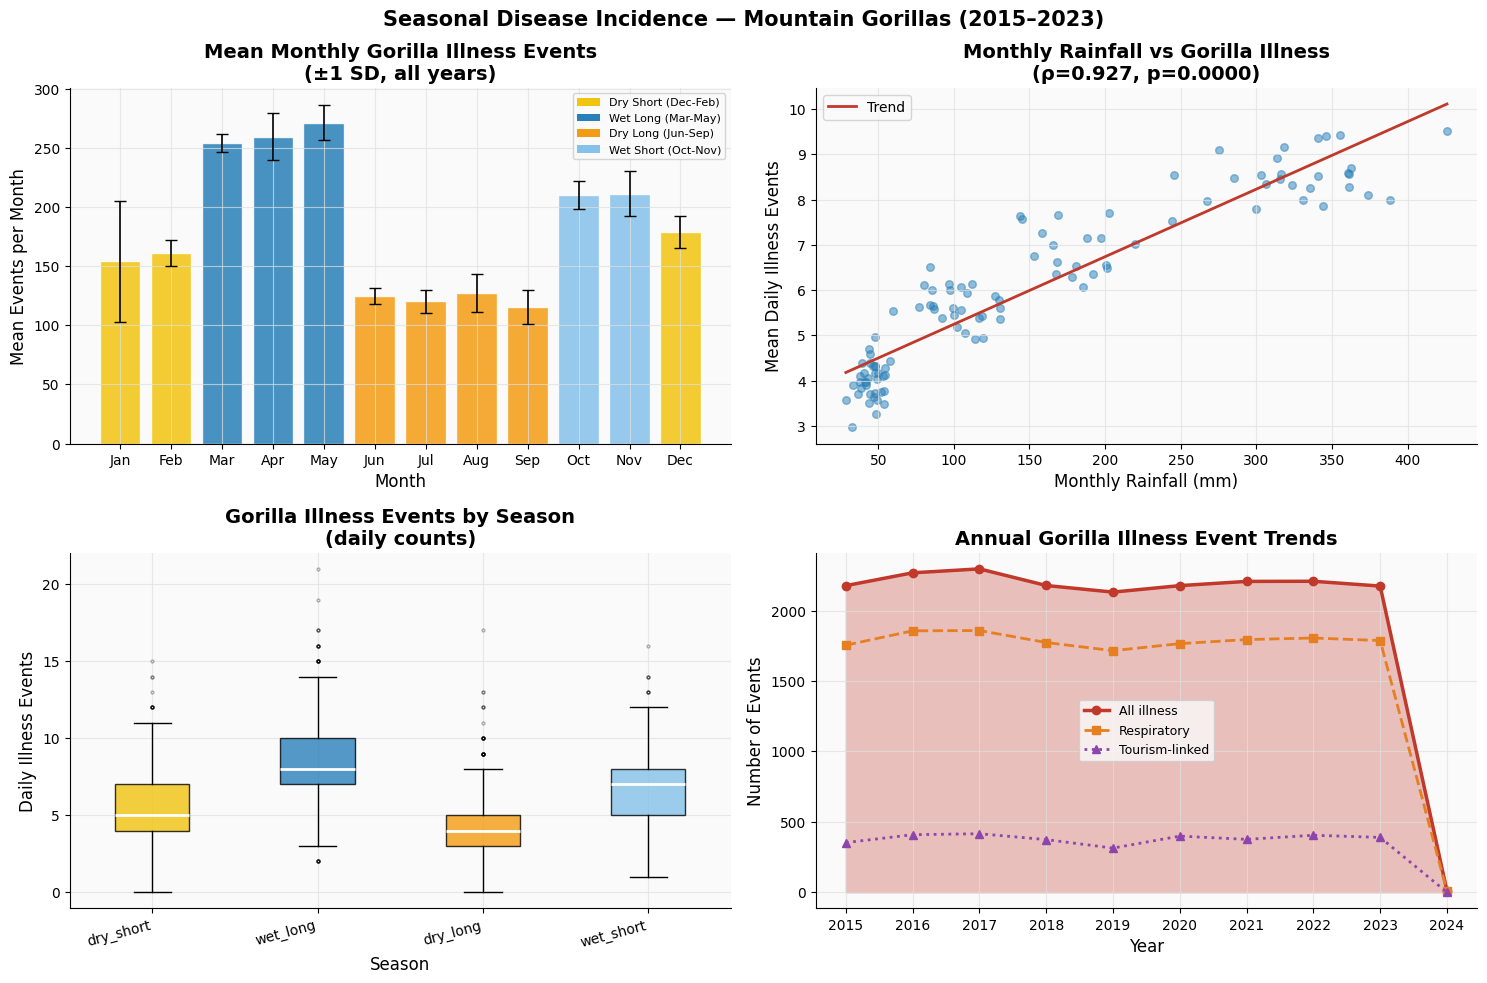

In [5]:
# ── Monthly aggregation ─────────────────────────────────────────────────────────
monthly_illness = (
    gorilla_health_df
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='event_count')
)

# Average monthly illness across all years
avg_monthly = monthly_illness.groupby('month')['event_count'].agg(['mean', 'std']).reset_index()
avg_monthly['month_name'] = pd.to_datetime(avg_monthly['month'], format='%m').dt.strftime('%b')

set_style()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel A: Average monthly illness
month_colors = [
    PALETTE.get('dry_short', '#F1C40F') if m in [12, 1, 2] else
    PALETTE.get('wet_long', '#2980B9') if m in [3, 4, 5] else
    PALETTE.get('dry_long', '#F39C12') if m in [6, 7, 8, 9] else
    PALETTE.get('wet_short', '#85C1E9')
    for m in avg_monthly['month']
]

bars = axes[0, 0].bar(
    avg_monthly['month_name'], avg_monthly['mean'],
    color=month_colors, edgecolor='white', alpha=0.85,
    yerr=avg_monthly['std'], capsize=4,
    error_kw={'linewidth': 1.2},
)
axes[0, 0].set_title('Mean Monthly Gorilla Illness Events\n(±1 SD, all years)')
axes[0, 0].set_ylabel('Mean Events per Month')
axes[0, 0].set_xlabel('Month')

# Add season legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE['dry_short'], label='Dry Short (Dec-Feb)'),
    Patch(facecolor=PALETTE['wet_long'],  label='Wet Long (Mar-May)'),
    Patch(facecolor=PALETTE['dry_long'],  label='Dry Long (Jun-Sep)'),
    Patch(facecolor=PALETTE['wet_short'], label='Wet Short (Oct-Nov)'),
]
axes[0, 0].legend(handles=legend_elements, fontsize=8, loc='upper right')

# Panel B: Rainfall vs illness scatter
merged_monthly = merged_daily.copy()
merged_monthly['period'] = pd.to_datetime(merged_monthly['date']).dt.to_period('M').dt.to_timestamp()
monthly_agg = merged_monthly.groupby('period').agg(
    total_rainfall=('rainfall_mm', 'sum'),
    mean_illness=('daily_illness_count', 'mean'),
).reset_index()

axes[0, 1].scatter(
    monthly_agg['total_rainfall'], monthly_agg['mean_illness'],
    alpha=0.5, color='#2980B9', s=30
)
# Add regression line
z = np.polyfit(monthly_agg['total_rainfall'], monthly_agg['mean_illness'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(monthly_agg['total_rainfall'].min(), monthly_agg['total_rainfall'].max(), 100)
axes[0, 1].plot(x_line, p_line(x_line), color='#C0392B', linewidth=2, label='Trend')
rho, pval = stats.spearmanr(monthly_agg['total_rainfall'], monthly_agg['mean_illness'])
axes[0, 1].set_title(f'Monthly Rainfall vs Gorilla Illness\n(ρ={rho:.3f}, p={pval:.4f})')
axes[0, 1].set_xlabel('Monthly Rainfall (mm)')
axes[0, 1].set_ylabel('Mean Daily Illness Events')
axes[0, 1].legend()

# Panel C: Season box plots
season_order = ['dry_short', 'wet_long', 'dry_long', 'wet_short']
season_colors = [PALETTE.get(s, '#95A5A6') for s in season_order]
box_data = [merged_daily[merged_daily['season']==s]['daily_illness_count'].values
            for s in season_order]
bp = axes[1, 0].boxplot(
    box_data, labels=season_order, patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1, 0].set_xticklabels(season_order, rotation=15, ha='right')
axes[1, 0].set_title('Gorilla Illness Events by Season\n(daily counts)')
axes[1, 0].set_ylabel('Daily Illness Events')
axes[1, 0].set_xlabel('Season')

# Panel D: Year-over-year trend
annual_summary = (
    gorilla_health_df.groupby('year')
    .agg(
        total_events=('event_id', 'count'),
        respiratory=('illness_type', lambda x: (x=='respiratory').sum()),
        tourism_linked=('transmission_source', lambda x: (x=='tourism_linked').sum()),
    )
    .reset_index()
)

axes[1, 1].fill_between(annual_summary['year'], annual_summary['total_events'],
                         alpha=0.3, color='#C0392B')
axes[1, 1].plot(annual_summary['year'], annual_summary['total_events'],
                marker='o', color='#C0392B', linewidth=2.5, label='All illness')
axes[1, 1].plot(annual_summary['year'], annual_summary['respiratory'],
                marker='s', color='#E67E22', linewidth=2, linestyle='--', label='Respiratory')
axes[1, 1].plot(annual_summary['year'], annual_summary['tourism_linked'],
                marker='^', color='#8E44AD', linewidth=2, linestyle=':', label='Tourism-linked')
axes[1, 1].set_title('Annual Gorilla Illness Event Trends')
axes[1, 1].set_ylabel('Number of Events')
axes[1, 1].set_xlabel('Year')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_xticks(annual_summary['year'])

fig.suptitle('Seasonal Disease Incidence — Mountain Gorillas (2015–2023)', fontsize=15)
plt.tight_layout()
save_fig(fig, '05_seasonal_patterns.png', str(FIG_DIR) + '/')
plt.show()

## Cell 6 — Group × Month Heatmap

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/05_group_month_heatmap.png


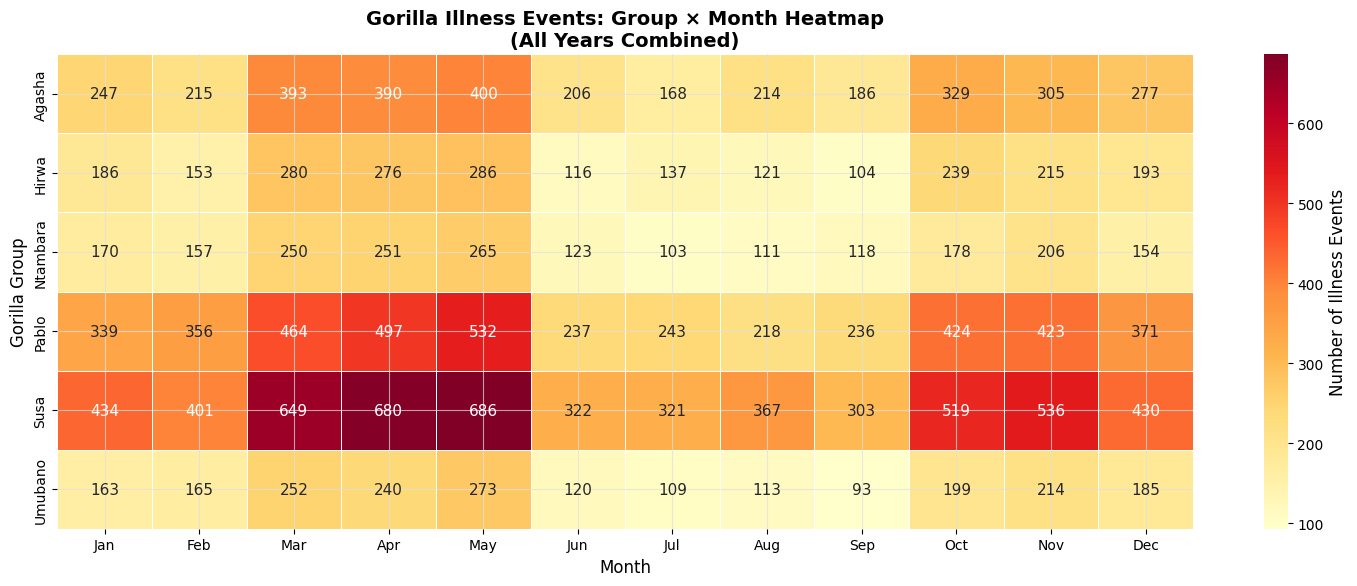

In [6]:
fig, ax = plot_group_month_heatmap(gorilla_health_df, figsize=(15, 6))
save_fig(fig, '05_group_month_heatmap.png', str(FIG_DIR) + '/')
plt.show()

## Cell 7 — Time Series Decomposition (Trend + Seasonal + Residual)

Seasonal indices by month (>1 = above annual average):
month_num
January      0.846
February     0.883
March        1.397
April        1.425
May          1.491
June         0.686
July         0.660
August       0.698
September    0.635
October      1.153
November     1.159
December     0.983
  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/05_time_series_decomposition.png


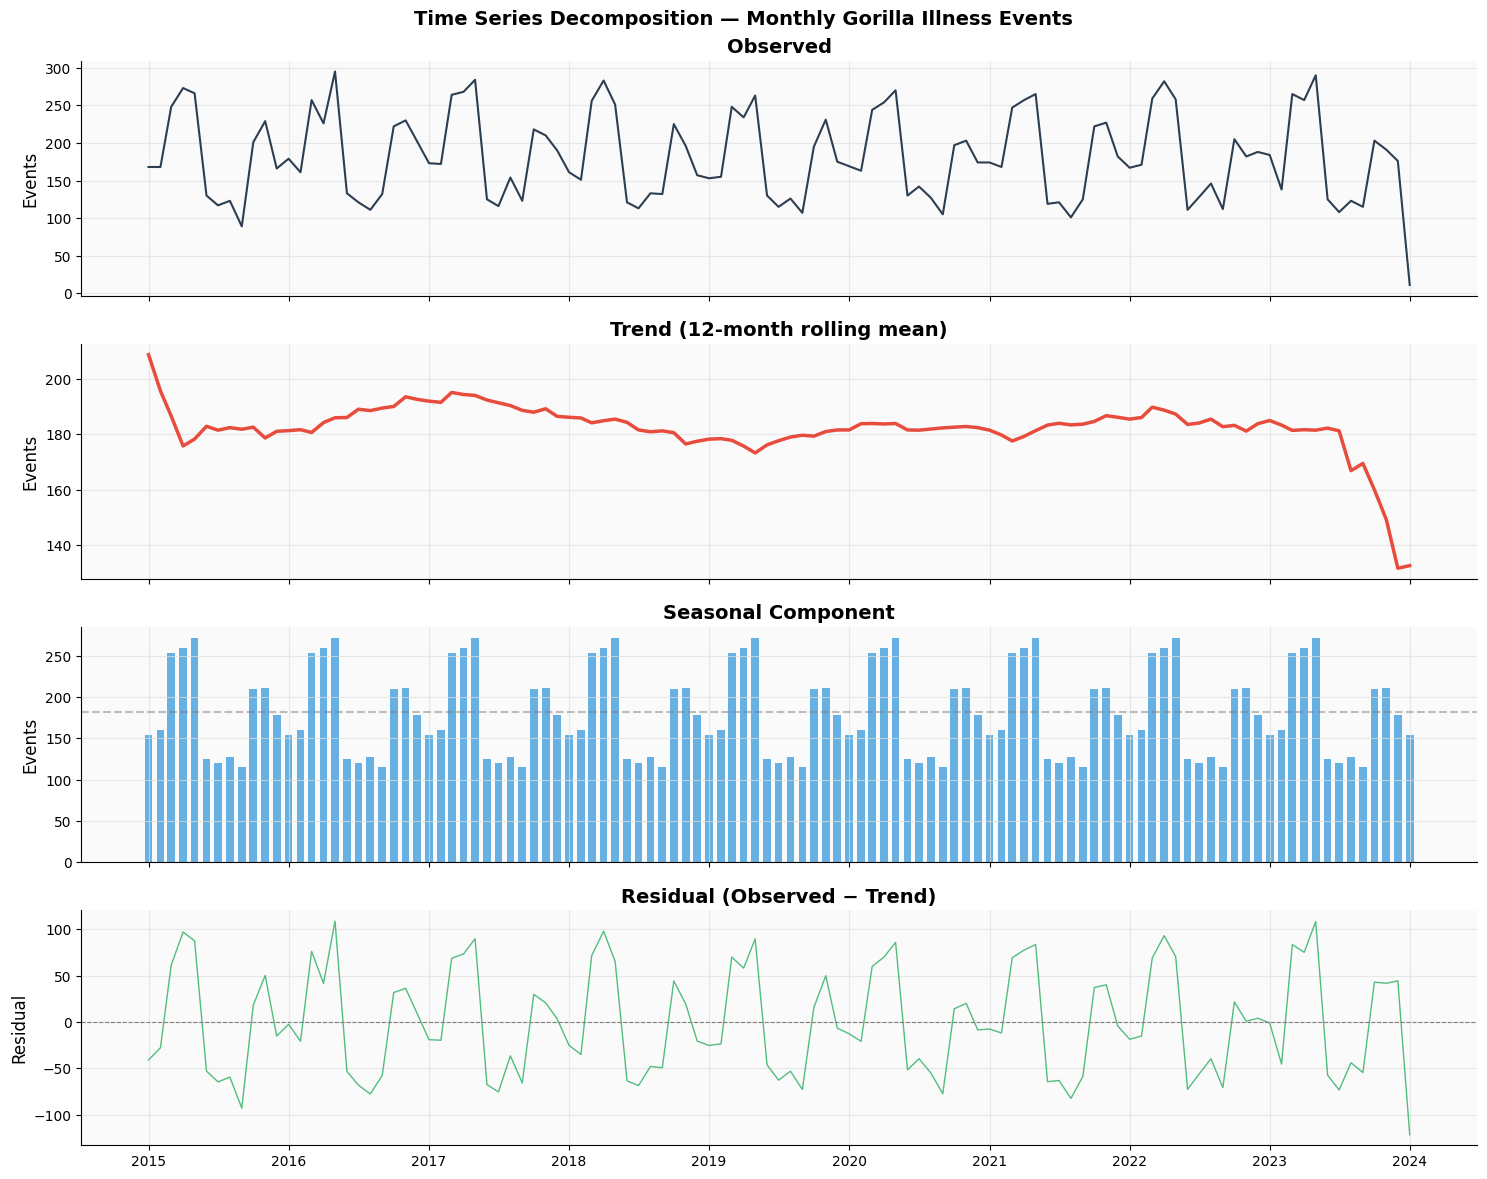

In [7]:
# ── Monthly time series for decomposition ─────────────────────────────────────
ts_data = (
    gorilla_health_df
    .groupby('month_year')
    .size()
    .reset_index(name='event_count')
)
ts_data['date'] = ts_data['month_year'].dt.to_timestamp()
ts_data = ts_data.sort_values('date').reset_index(drop=True)

# ── Manual decomposition (avoids statsmodels dependency) ──────────────────────
# Trend: 12-month rolling average
ts_data['trend'] = ts_data['event_count'].rolling(window=12, center=True, min_periods=6).mean()

# Seasonal: average by month-of-year (averaged across all years)
ts_data['month_num'] = ts_data['date'].dt.month
monthly_avg = ts_data.groupby('month_num')['event_count'].mean()
overall_avg = ts_data['event_count'].mean()
seasonal_indices = monthly_avg / overall_avg
ts_data['seasonal_index'] = ts_data['month_num'].map(seasonal_indices)
ts_data['seasonal_component'] = ts_data['seasonal_index'] * overall_avg

# Residual
ts_data['residual'] = ts_data['event_count'] - ts_data['trend'].fillna(ts_data['event_count'].mean())

print('Seasonal indices by month (>1 = above annual average):')
si_named = pd.Series(
    seasonal_indices.values,
    index=pd.to_datetime(seasonal_indices.index, format='%m').strftime('%B')
)
print(si_named.round(3).to_string())

# ── Plot decomposition ─────────────────────────────────────────────────────────
set_style()
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(ts_data['date'], ts_data['event_count'], color='#2C3E50', linewidth=1.5)
axes[0].set_ylabel('Events')
axes[0].set_title('Observed')

axes[1].plot(ts_data['date'], ts_data['trend'], color='#E74C3C', linewidth=2.5)
axes[1].set_ylabel('Events')
axes[1].set_title('Trend (12-month rolling mean)')

axes[2].bar(ts_data['date'], ts_data['seasonal_component'],
            color='#3498DB', alpha=0.75, width=20)
axes[2].axhline(overall_avg, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Events')
axes[2].set_title('Seasonal Component')

axes[3].plot(ts_data['date'], ts_data['residual'],
             color='#27AE60', linewidth=1, alpha=0.8)
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual (Observed − Trend)')
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Time Series Decomposition — Monthly Gorilla Illness Events', fontsize=14)
plt.tight_layout()
save_fig(fig, '05_time_series_decomposition.png', str(FIG_DIR) + '/')
plt.show()

## Cell 8 — Maternal Transmission: Infant vs Non-infant Seasonality

Maternal intragroup events:  3,015
Tourism-linked events:        3,436
Background seasonal events:   13,385
  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/05_transmission_seasonality.png


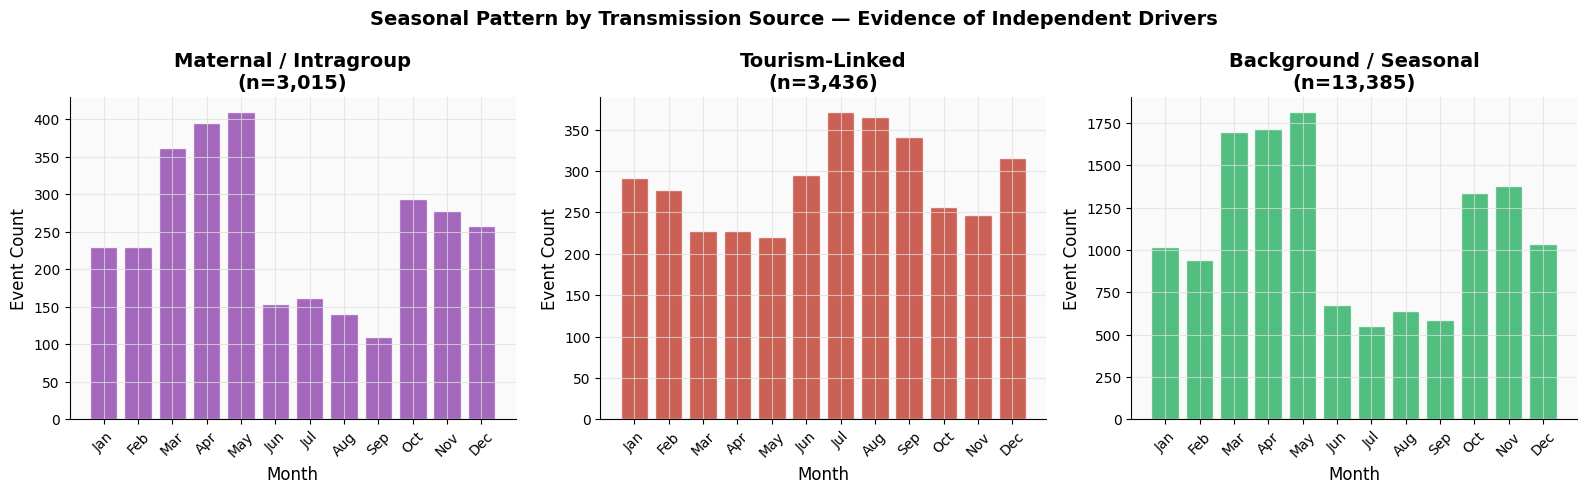


✅ Notebook 05 complete. Proceed to 06_risk_modeling.ipynb


In [8]:
# ── Compare maternal intragroup vs tourism-linked transmission seasonality ──────
maternal_events  = gorilla_health_df[gorilla_health_df['transmission_source'] == 'maternal_intragroup'].copy()
tourism_events   = gorilla_health_df[gorilla_health_df['transmission_source'] == 'tourism_linked'].copy()
background_events = gorilla_health_df[gorilla_health_df['transmission_source'] == 'background_seasonal'].copy()

print(f'Maternal intragroup events:  {len(maternal_events):,}')
print(f'Tourism-linked events:        {len(tourism_events):,}')
print(f'Background seasonal events:   {len(background_events):,}')

set_style()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, df, title, color in zip(
    axes,
    [maternal_events, tourism_events, background_events],
    ['Maternal / Intragroup', 'Tourism-Linked', 'Background / Seasonal'],
    ['#8E44AD', '#C0392B', '#27AE60'],
):
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    month_counts = df.groupby('month').size().reindex(range(1, 13), fill_value=0)
    month_names = pd.to_datetime(month_counts.index, format='%m').strftime('%b')
    ax.bar(month_names, month_counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{title}\n(n={len(df):,})')
    ax.set_xlabel('Month')
    ax.set_ylabel('Event Count')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Seasonal Pattern by Transmission Source — Evidence of Independent Drivers', fontsize=14)
plt.tight_layout()
save_fig(fig, '05_transmission_seasonality.png', str(FIG_DIR) + '/')
plt.show()

print('\n✅ Notebook 05 complete. Proceed to 06_risk_modeling.ipynb')